In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import joblib

In [2]:
# Load Dataset
df = pd.read_csv(R"C:\Users\nisha\Downloads\titanic.csv")

print(df.head())
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [5]:
# Select Features & Target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]
y = df[target]
X
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [12]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train
y_train


692    1
481    0
527    0
855    1
801    1
      ..
359    1
258    1
736    0
462    0
507    1
Name: Survived, Length: 712, dtype: int64

In [13]:
# Define Preprocessing
numeric_features = ['Age', 'Fare']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
numeric_features
numeric_pipeline


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [14]:
# Categorical Features
categorical_features = ['Sex', 'Embarked', 'Pclass']

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
categorical_features
categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [15]:
# Combine Both Numeric_features and Categorical Features
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])
preprocessor
 

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Embarked', 'Pclass'])])

In [16]:
# Build ML Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Pclass'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [17]:
# Train Model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Pclass'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [19]:
# Make Predictions
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred
y_prob

array([0.08858673, 0.04721058, 0.14343752, 0.05180664, 0.68711668,
       0.44329736, 0.73806259, 0.30732346, 0.41024811, 0.19885099,
       0.15047659, 0.11192188, 0.5154389 , 0.31277514, 0.57403866,
       0.16597392, 0.50752996, 0.07603524, 0.10756652, 0.75072107,
       0.07603524, 0.80527141, 0.07260263, 0.45225692, 0.07486219,
       0.94955007, 0.15047659, 0.29193775, 0.11720019, 0.1196496 ,
       0.06413637, 0.91844336, 0.11973593, 0.08459815, 0.13698527,
       0.15720524, 0.13755514, 0.6149785 , 0.15047659, 0.8368221 ,
       0.16824062, 0.96293987, 0.13321958, 0.84096674, 0.74602358,
       0.09551457, 0.07614129, 0.40875536, 0.80875537, 0.88098425,
       0.89645309, 0.5030003 , 0.68535346, 0.22722704, 0.61945502,
       0.08208844, 0.07662574, 0.38219488, 0.56490789, 0.39014565,
       0.62567951, 0.75970763, 0.11086884, 0.14273922, 0.42184327,
       0.59186516, 0.94260478, 0.06625575, 0.20767997, 0.2545817 ,
       0.75977661, 0.11885916, 0.68538056, 0.93842802, 0.20189

In [20]:
# Evaluation
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



[[92 18]
 [23 46]]


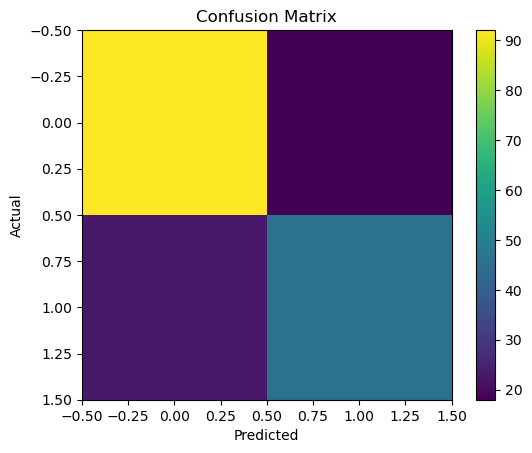

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [22]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8342555994729908


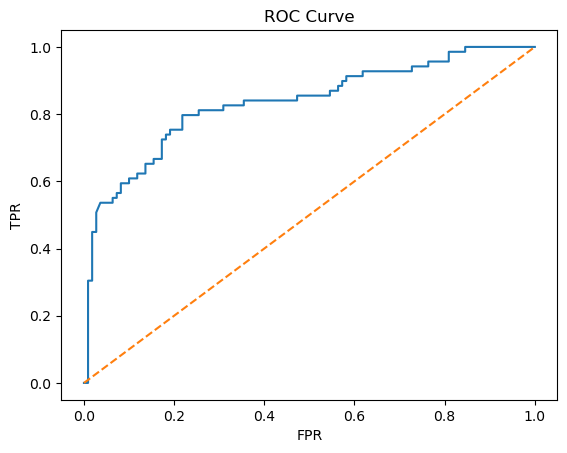

In [23]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [24]:
# Cross Validation
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')

print("Scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

Scores: [0.83306983 0.83502674 0.84926471 0.84278075 0.86743784]
Mean: 0.8455159723896084
Std: 0.01238574417106465


In [25]:
# Save Model
joblib.dump(pipeline, "titanic_model.joblib")

#joblib is used to save and load trained models so we don’t need to train them again every time.



['titanic_model.joblib']

In [27]:
# Load & Predict
loaded_model = joblib.load("titanic_model.joblib")

sample = X_test.iloc[:5]
predictions = loaded_model.predict(sample)

print(predictions)

[0 0 0 0 1]
